In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1)Loading Data set

In [9]:
df = pd.read_csv('cyber_data.csv')

2)Preview

In [10]:
print(df.shape)
print(df.columns)
df.head()

(77623, 18)
Index(['AttackDate', 'Country', 'Spam', 'Ransomware', 'Local Infection',
       'Exploit', 'Malicious Mail', 'Network Attack', 'On Demand Scan',
       'Web Threat', 'Rank Spam', 'Rank Ransomware', 'Rank Local Infection',
       'Rank Exploit', 'Rank Malicious Mail', 'Rank Network Attack',
       'Rank On Demand Scan', 'Rank Web Threat'],
      dtype='object')


,AttackDate,Country,Spam,Ransomware,Local Infection,Exploit,Malicious Mail,Network Attack,On Demand Scan,Web Threat,Rank Spam,Rank Ransomware,Rank Local Infection,Rank Exploit,Rank Malicious Mail,Rank Network Attack,Rank On Demand Scan,Rank Web Threat
0,11/10/2022 0:00,Arab Republic of Egypt,0.00090,0.00013,0.01353,0.00013,0.00287,0.01007,0.01148,0.01708,68,47,85,176,34,11,78,53
1,11/10/2022 0:00,Argentine Republic,0.00601,0.00006,0.00575,0.00035,0.00058,0.00095,0.00482,0.00974,27,86,174,128,140,138,174,160
2,11/10/2022 0:00,Aruba,NaN,NaN,0.01384,NaN,0.00092,NaN,0.00830,0.00554,162,143,82,186,104,187,119,190
3,11/10/2022 0:00,Bailiwick of Guernsey,NaN,NaN,0.00546,0.00273,NaN,0.00091,0.00546,0.01001,162,143,179,1,186,141,164,159
4,11/10/2022 0:00,Bailiwick of Jersey,0.00003,NaN,0.00774,0.00101,0.00067,NaN,0.00707,0.01145,138,143,150,31,133,187,137,146


3)Converting AttackDate to Datetime

In [11]:
df['AttackDate'] = pd.to_datetime(df['AttackDate'], format="%d/%m/%Y %H:%M")
df.set_index('AttackDate', inplace=True)


4)Handle Duplicates and Missing values

In [12]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

4)Creating totalthreats column

In [13]:
threats=['Spam','Ransomware','Local Infection','Exploit','Malicious Mail','Network Attack','On Demand Scan','Web Threat']
df['TotalThreats'] = df[threats].sum(axis=1)
df.head()

,Country,Spam,Ransomware,Local Infection,Exploit,Malicious Mail,Network Attack,On Demand Scan,Web Threat,Rank Spam,Rank Ransomware,Rank Local Infection,Rank Exploit,Rank Malicious Mail,Rank Network Attack,Rank On Demand Scan,Rank Web Threat,TotalThreats
AttackDate,,,,,,,,,,,,,,,,,,
2022-10-11,Arab Republic of Egypt,0.00090,0.00013,0.01353,0.00013,0.00287,0.01007,0.01148,0.01708,68,47,85,176,34,11,78,53,0.05619
2022-10-11,Argentine Republic,0.00601,0.00006,0.00575,0.00035,0.00058,0.00095,0.00482,0.00974,27,86,174,128,140,138,174,160,0.02826
2022-10-11,Bolivarian Republic of Venezuela,0.00058,0.00017,0.01692,0.00033,0.00053,0.00761,0.01450,0.01623,79,34,65,133,147,17,54,68,0.05687
2022-10-11,Burkina Faso,0.00005,0.00004,0.01518,0.00032,0.00011,0.00017,0.00858,0.00572,130,109,76,136,182,184,116,187,0.03017
2022-10-11,Canada,0.00913,0.00002,0.00714,0.00184,0.00043,0.00141,0.00580,0.01306,17,135,161,4,157,110,158,120,0.03883


5)Extract based on time

In [14]:
df['day'] = df.index.day
df['month'] = df.index.month
df['year'] = df.index.year
print(df[['day', 'month', 'year']].head())


            day  month  year
AttackDate                  
2022-10-11   11     10  2022
2022-10-11   11     10  2022
2022-10-11   11     10  2022
2022-10-11   11     10  2022
2022-10-11   11     10  2022


6) Lag feature

In [15]:
df['lag1'] = df['TotalThreats'].shift(1)
df['lag2'] = df['TotalThreats'].shift(2)
df.dropna(inplace=True)
df.head()
print(df[['TotalThreats', 'lag1', 'lag2']].head(10))

            TotalThreats     lag1     lag2
AttackDate                                
2022-10-11       0.05687  0.02826  0.05619
2022-10-11       0.03017  0.05687  0.02826
2022-10-11       0.03883  0.03017  0.05687
2022-10-11       0.03396  0.03883  0.03017
2022-10-11       0.06894  0.03396  0.03883
2022-10-11       0.03218  0.06894  0.03396
2022-10-11       0.06612  0.03218  0.06894
2022-10-11       0.03401  0.06612  0.03218
2022-10-11       0.07197  0.03401  0.06612
2022-10-11       0.06376  0.07197  0.03401


7) Rolling Average

In [16]:
df['roll_mean_7'] = df['TotalThreats'].rolling(window=7).mean()
df.dropna(inplace=True)
print(df[['TotalThreats', 'roll_mean_7']].head(10))

            TotalThreats  roll_mean_7
AttackDate                           
2022-10-11       0.06612     0.046724
2022-10-11       0.03401     0.043459
2022-10-11       0.07197     0.049430
2022-10-11       0.06376     0.052991
2022-10-11       0.06556     0.057506
2022-10-11       0.03682     0.052917
2022-10-11       0.06734     0.057940
2022-10-11       0.05452     0.056283
2022-10-11       0.07616     0.062304
2022-10-11       0.04321     0.058196


8) Encoding Country

In [17]:
df['Country_encoded'] = df['Country'].map(df['Country'].value_counts())
print(df[['Country', 'Country_encoded']].head())



                                               Country  Country_encoded
AttackDate                                                             
2022-10-11  Democratic Socialist Republic of Sri Lanka              312
2022-10-11                          Dominican Republic              285
2022-10-11     Federal Democratic Republic of Ethiopia              304
2022-10-11        Federal Democratic Republic of Nepal              313
2022-10-11                 Federal Republic of Germany              316




> EDA



1) Total Threats over time

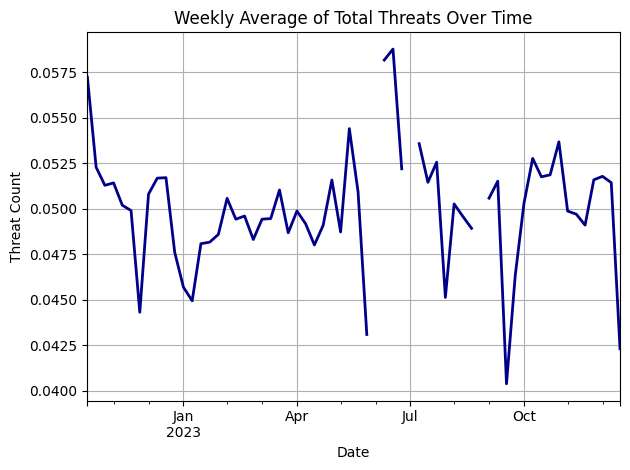

In [18]:
#to reduce clutter resampled data into weekly average
weekly_df = df['TotalThreats'].resample('W').mean()
weekly_df.plot(color='darkblue', linewidth=2)
plt.title('Weekly Average of Total Threats Over Time')
plt.xlabel('Date')
plt.ylabel('Threat Count')
plt.grid(True)
plt.tight_layout()
plt.show()


2) Rolling Average

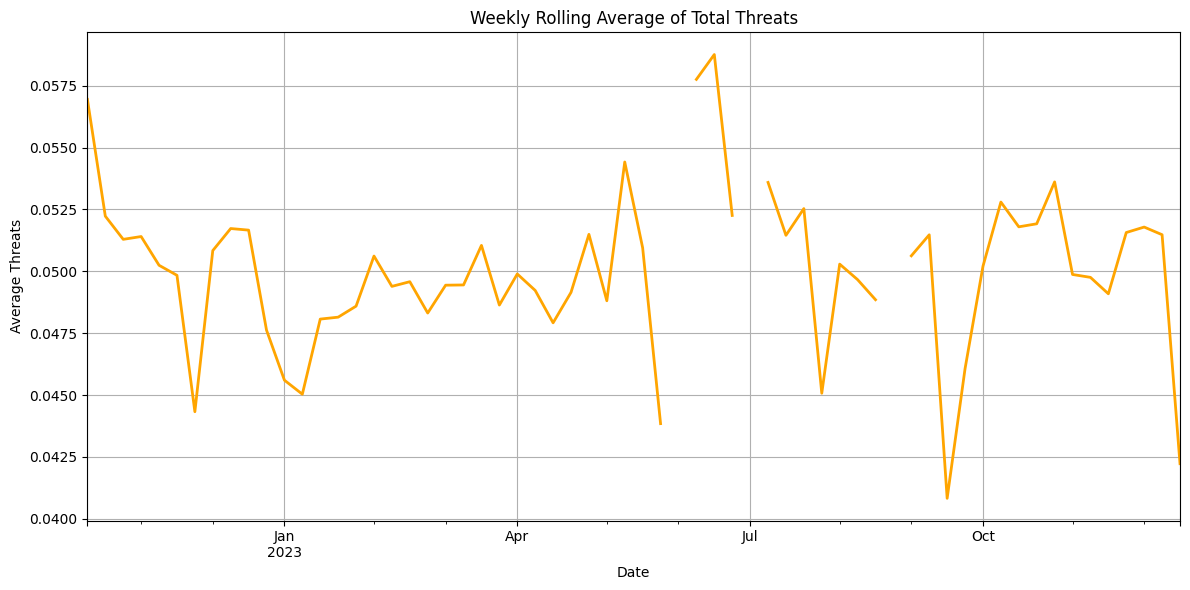

In [19]:
weekly_roll = df['roll_mean_7'].resample('W').mean()
plt.figure(figsize=(12,6))
weekly_roll.plot(color='orange', linewidth=2)
plt.title('Weekly Rolling Average of Total Threats')
plt.xlabel('Date')
plt.ylabel('Average Threats')
plt.grid(True)
plt.tight_layout()
plt.show()



3) Zoom into January 2023

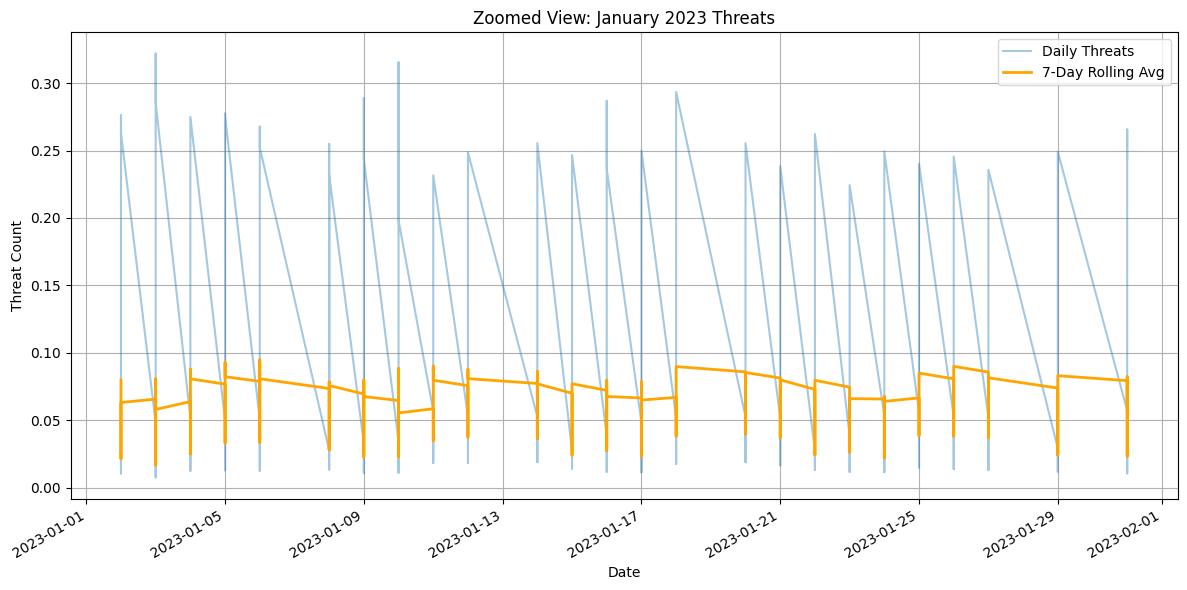

In [20]:

zoom_df = df['2023-01-01':'2023-01-31']

plt.figure(figsize=(12,6))
zoom_df['TotalThreats'].plot(label='Daily Threats', alpha=0.4)
zoom_df['roll_mean_7'].plot(label='7-Day Rolling Avg', color='orange', linewidth=2)
plt.title('Zoomed View: January 2023 Threats')
plt.xlabel('Date')
plt.ylabel('Threat Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



4) Correlation Heatmap(Threat types)

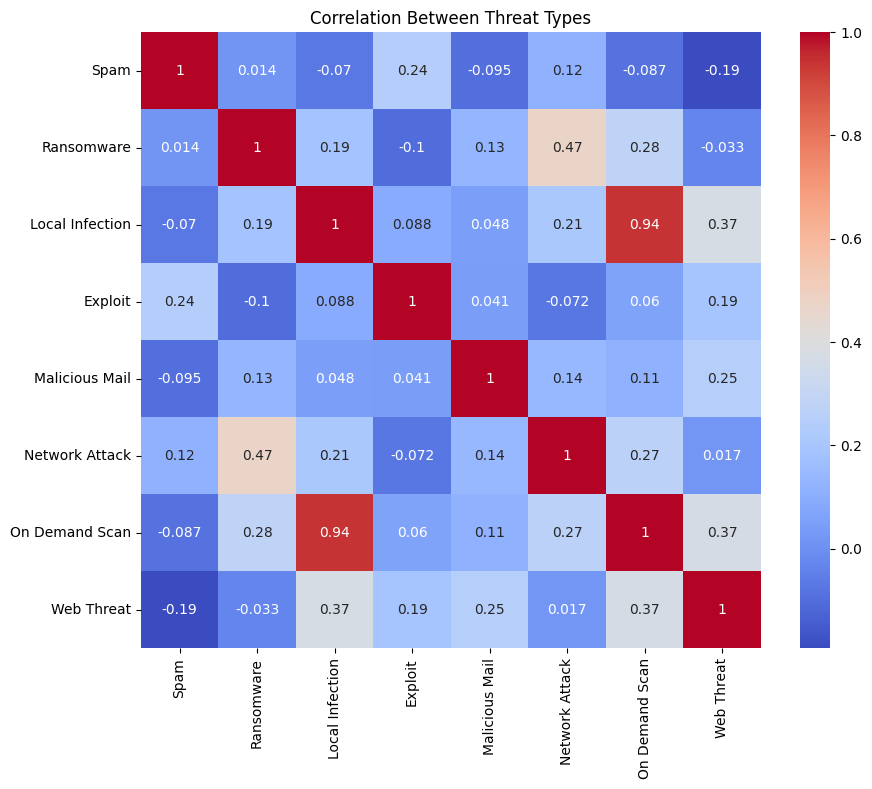

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df[threats].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Threat Types')
plt.show()

5)Threat type Comparison

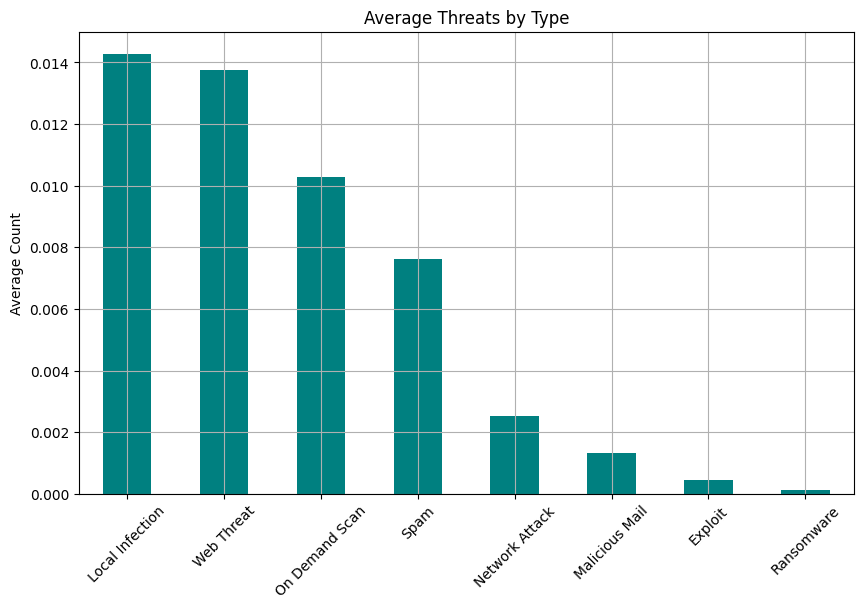

In [22]:
avg_threats = df[threats].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_threats.plot(kind='bar', color='teal')
plt.title('Average Threats by Type')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

6)Detect Outliers

7)Country wise threats

> Modeling



1) Preparing Feature and Targets

In [31]:
from sklearn.model_selection import train_test_split

features = ['lag1', 'lag2', 'roll_mean_7', 'day', 'month', 'year', 'Country_encoded']
X = df[features]
y = df['TotalThreats']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (31976, 7)
Testing size: (7994, 7)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


2)Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, lr_preds)
rmse_lr = mean_squared_error(y_test, lr_preds)
r2_lr = r2_score(y_test, lr_preds)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

MAE: 0.015733250716241175
RMSE: 0.0006208515184775716
R²: 0.22564529746548767


3)Desicion Tree

In [42]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, dt_preds)
rmse_dt = mean_squared_error(y_test, dt_preds)
r2_dt = r2_score(y_test, dt_preds)

print("Decision Tree Results:")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

Decision Tree Results:
MAE: 0.011941289717287966
RMSE: 0.00041834962788341257
R²: 0.4782150127465836


4)SVM Regressor

In [43]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

# Evaluation
mae_svm = mean_absolute_error(y_test, svm_preds)
rmse_svm = mean_squared_error(y_test, svm_preds)
r2_svm = r2_score(y_test, svm_preds)

print("SVM Results:")
print("MAE:", mae_svm)
print("RMSE:", rmse_svm)
print("R²:", r2_svm)

SVM Results:
MAE: 0.059593147134664966
RMSE: 0.004161917105301892
R²: -4.190935330161023


5) Lasso Regression

In [35]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
lasso_preds = lasso_model.predict(X_test_scaled)

mae_lasso = mean_absolute_error(y_test, lasso_preds)
rmse_lasso = mean_squared_error(y_test, lasso_preds)
r2_lasso = r2_score(y_test, lasso_preds)

print("Lasso Regression Results:")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R²:", r2_lasso)

Lasso Regression Results:
MAE: 0.017504495001223395
RMSE: 0.0008026422278167672
R²: -0.0010924755194006153


6)Random Forest

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_preds)
rmse_rf = mean_squared_error(y_test, rf_preds)
r2_rf = r2_score(y_test, rf_preds)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results:
MAE: 0.008995872629472105
RMSE: 0.00022792060496492118
R²: 0.715726889592083


5)Compare

In [44]:
import pandas as pd

results = {
    'Model': ['Linear Regression', 'Decision Tree', 'SVM'],
    'MAE': [mae_lr, mae_dt, mae_svm],
    'RMSE': [rmse_lr, rmse_dt, rmse_svm],
    'R²': [r2_lr, r2_dt, r2_svm]
}

results_df = pd.DataFrame(results)
print("Model Comparison:")
print(results_df)


Model Comparison:
               Model       MAE      RMSE        R²
0  Linear Regression  0.015733  0.000621  0.225645
1      Decision Tree  0.011941  0.000418  0.478215
2                SVM  0.059593  0.004162 -4.190935


> Predictions VS Actual

1)LR Predictions

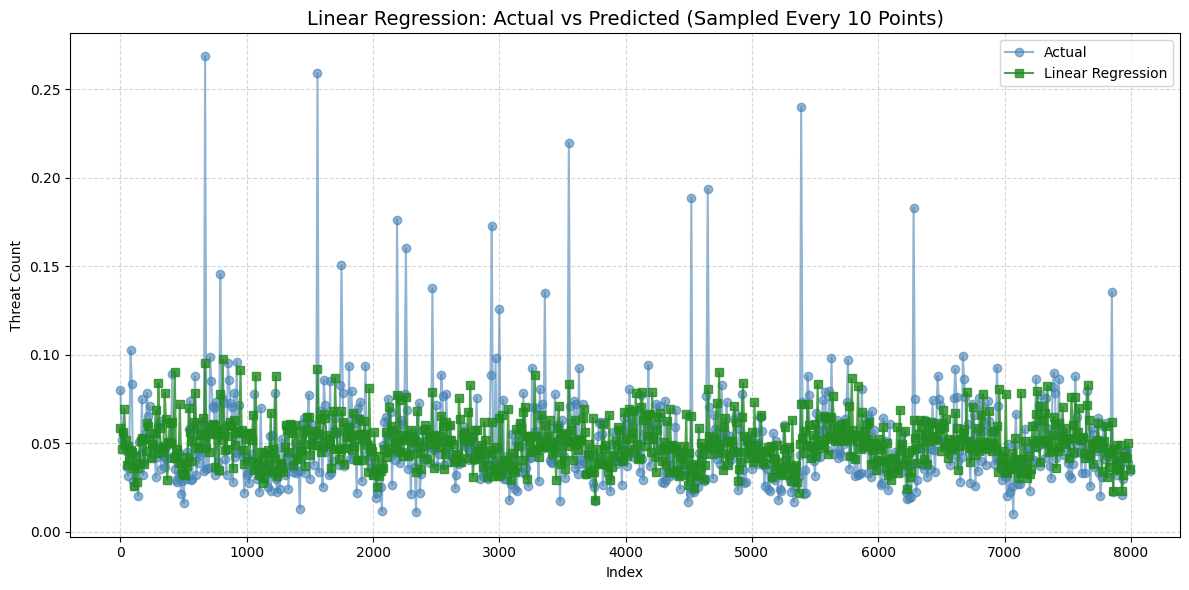

In [60]:
# Sample every 10th point for clarity
sample_idx = range(0, len(y_test), 10)

plt.figure(figsize=(12,6))

# Plot actual values with light markers
plt.plot(sample_idx, y_test.values[sample_idx], 'o-', label='Actual', color='steelblue', alpha=0.6)

# Plot predicted values with distinct markers
plt.plot(sample_idx, lr_preds[sample_idx], 's-', label='Linear Regression', color='forestgreen', alpha=0.8)

# Add title and labels
plt.title('Linear Regression: Actual vs Predicted (Sampled Every 10 Points)', fontsize=14)
plt.xlabel('Index')
plt.ylabel('Threat Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



2) DT Prediction

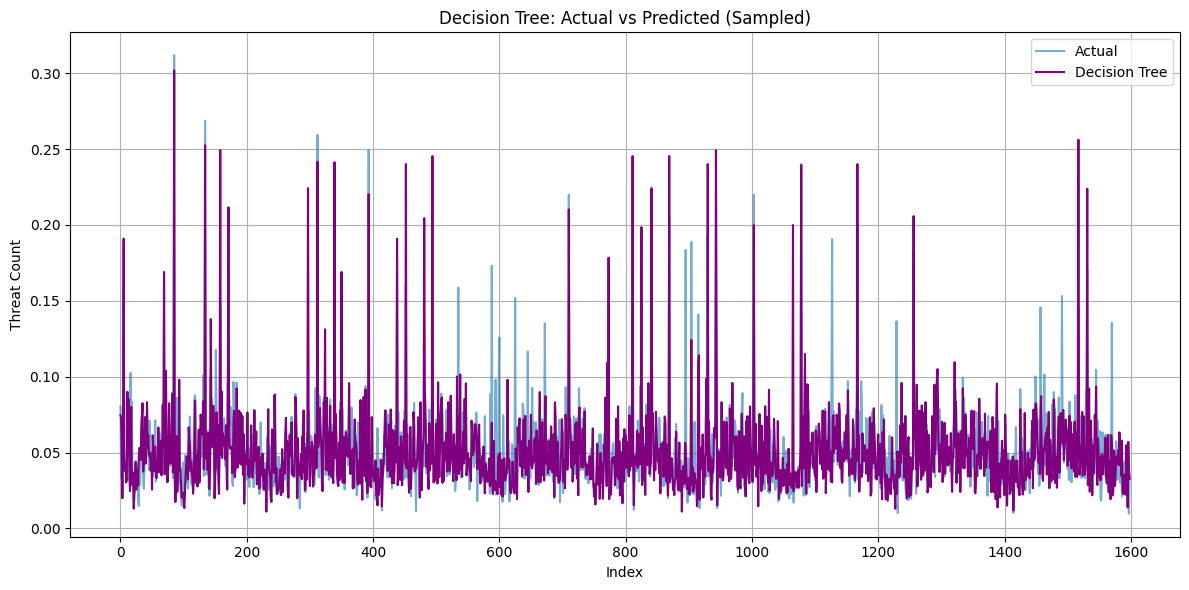

In [46]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[sample_idx], label='Actual', alpha=0.6)
plt.plot(dt_preds[sample_idx], label='Decision Tree', color='purple')
plt.title('Decision Tree: Actual vs Predicted (Sampled)')
plt.xlabel('Index')
plt.ylabel('Threat Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

SVM Prediction

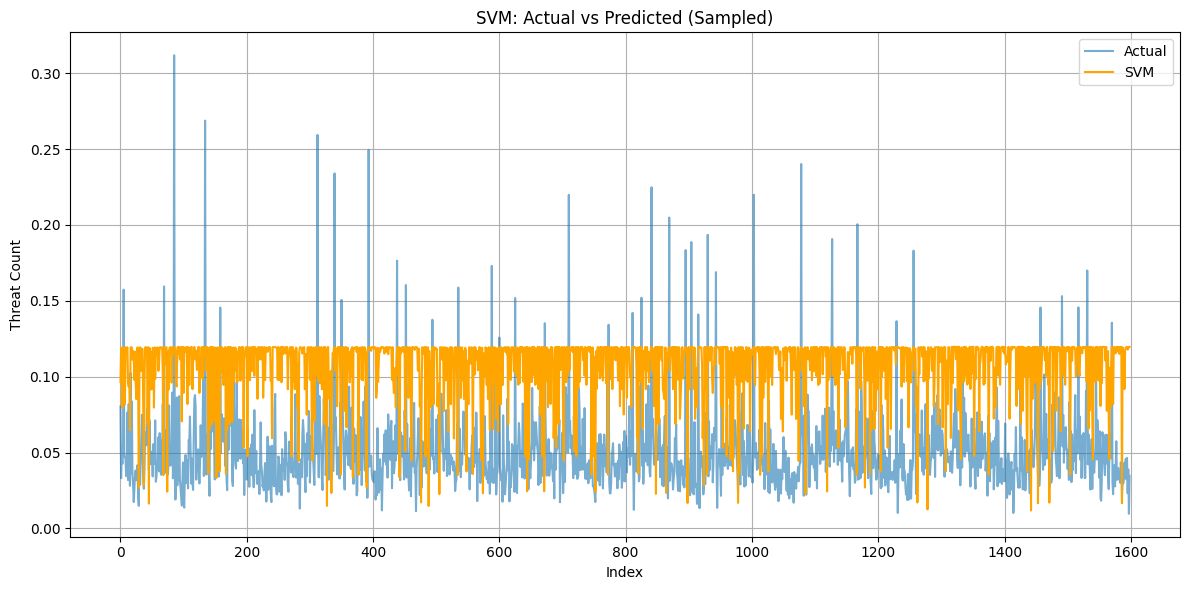

In [47]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[sample_idx], label='Actual', alpha=0.6)
plt.plot(svm_preds[sample_idx], label='SVM', color='orange')
plt.title('SVM: Actual vs Predicted (Sampled)')
plt.xlabel('Index')
plt.ylabel('Threat Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

4) First 50 predictions

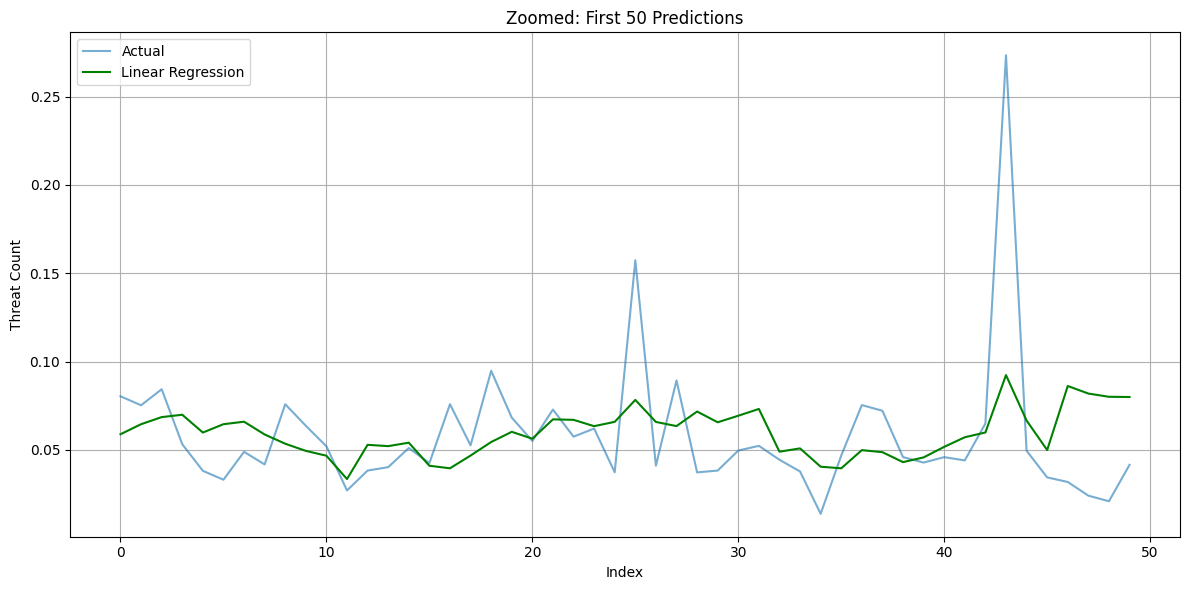

In [48]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:50], label='Actual', alpha=0.6)
plt.plot(lr_preds[:50], label='Linear Regression', color='green')
plt.title('Zoomed: First 50 Predictions')
plt.xlabel('Index')
plt.ylabel('Threat Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


5) Compare All Models

In [50]:
results = {
    'Model': ['Linear Regression', 'Decision Tree', 'SVM', 'Lasso Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_dt, mae_svm, mae_lasso, mae_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_svm, rmse_lasso, rmse_rf],
    'R²': [r2_lr, r2_dt, r2_svm, r2_lasso, r2_rf]
}

results_df = pd.DataFrame(results)
print("📊 Updated Model Comparison:")
print(results_df)


📊 Updated Model Comparison:
               Model       MAE      RMSE        R²
0  Linear Regression  0.015733  0.000621  0.225645
1      Decision Tree  0.011941  0.000418  0.478215
2                SVM  0.059593  0.004162 -4.190935
3   Lasso Regression  0.017504  0.000803 -0.001092
4      Random Forest  0.008996  0.000228  0.715727


1) Prediction of future 7 days

In [56]:
# Initialize forecast list
forecast = []
lag1 = df.iloc[-1]['TotalThreats']
lag2 = df.iloc[-1]['lag1']
roll_vals = df['TotalThreats'].tail(7).tolist()

for i in range(7):
    day = (last_date + pd.Timedelta(days=i+1)).day
    month = (last_date + pd.Timedelta(days=i+1)).month
    year = (last_date + pd.Timedelta(days=i+1)).year
    country = df.iloc[-1]['Country_encoded']
    roll_mean_7 = np.mean(roll_vals[-7:])

    # Create input row
    input_row = pd.DataFrame([[lag1, lag2, roll_mean_7, day, month, year, country]],
                             columns=features)

    # Predict
    pred = rf_model.predict(input_row)[0]
    forecast.append(pred)

    # Update lag and rolling values
    lag2 = lag1
    lag1 = pred
    roll_vals.append(pred)

# Create forecast DataFrame
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Predicted_Threats': forecast})
forecast_df.set_index('Date', inplace=True)
print(forecast_df)

            Predicted_Threats
Date                         
2023-12-12           0.097057
2023-12-13           0.089480
2023-12-14           0.228859
2023-12-15           0.084887
2023-12-16           0.056669
2023-12-17           0.298390
2023-12-18           0.092761


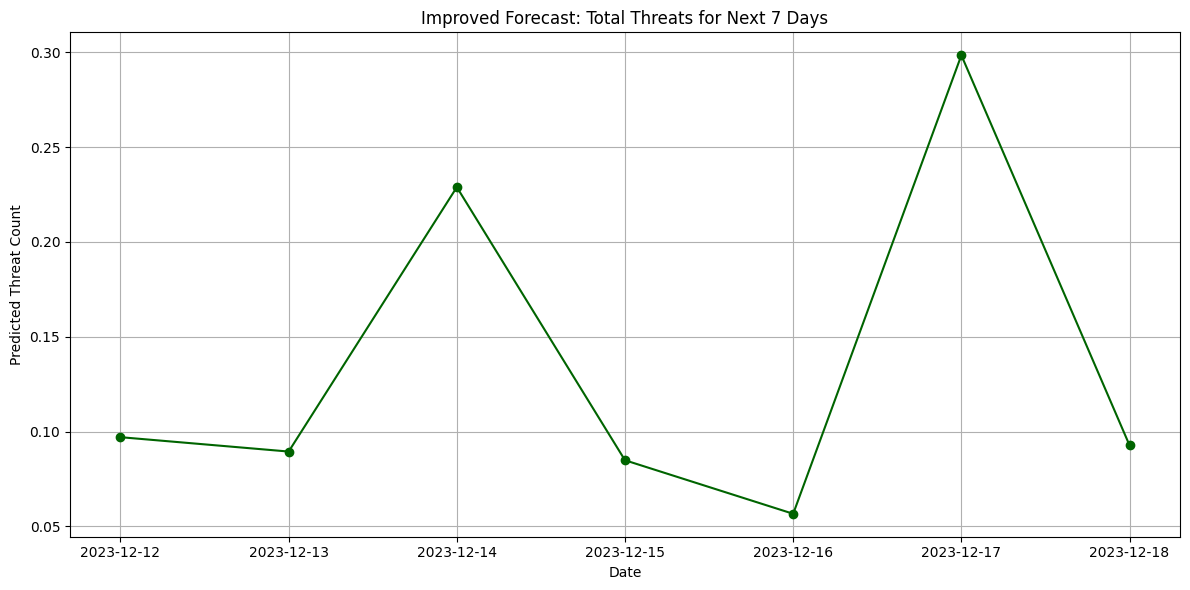

In [57]:
plt.figure(figsize=(12,6))
plt.plot(forecast_df.index, forecast_df['Predicted_Threats'], marker='o', color='darkgreen')
plt.title('Improved Forecast: Total Threats for Next 7 Days')
plt.xlabel('Date')
plt.ylabel('Predicted Threat Count')
plt.grid(True)
plt.tight_layout()
plt.show()